<h1 style="color: darkgray;font-family:san=serif;text-align:left;font-weight:bold;font-size:30px">Import Libraries</h1>

In [1]:
import sys
sys.path.insert(0, r"C:\Users\manpu\Downloads\Ambulence_call_volume_Shylender_Rao_Dissertation_final\Toshylandhar\Shylendar_Ambulence_Call_Volume_FE")

from lib_file import lib_path
print(lib_path)

C:\Users\manpu\Downloads\Ambulence_call_volume_Shylender_Rao_Dissertation_final\Toshylandhar\Shylendar_Ambulence_Call_Volume_FE


In [2]:
import sys
!{sys.executable} -m pip install --upgrade pip

In [3]:
!pip install scikit-learn

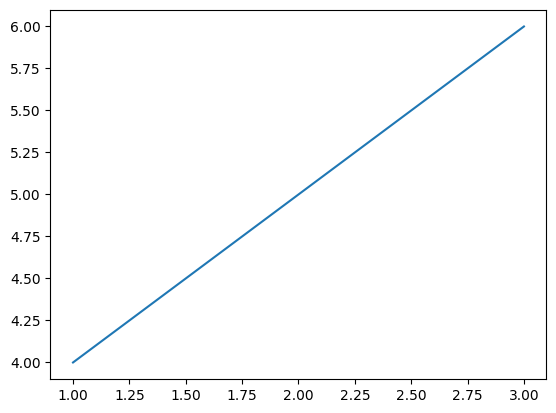

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from lib_file import lib_path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
plt.plot([1,2,3],[4,5,6])
plt.show()
import numpy as np

***Load the datasets from 'splitting'***

In [5]:
x_train = pd.read_csv('SplittedData/x_train.csv')
x_test = pd.read_csv('SplittedData/x_test.csv')
y_train = pd.read_csv('SplittedData/y_train.csv')
y_test = pd.read_csv('SplittedData/y_test.csv')



***Print the shape of the loaded datasets***

In [6]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(42828, 16) (10707, 16) (42828, 1) (10707, 1)


In [7]:
x_train

,station_id,year,month,day,hour,is_weekend,is_holiday,is_night,is_morning,is_afternoon,is_evening,hour_sin,hour_cos,month_sin,month_cos,season
0,0,2013,1,1,0,0,1,1,0,0,0,0.0,1.0,0.500000,0.866025,1
1,1,2013,1,1,0,0,1,1,0,0,0,0.0,1.0,0.500000,0.866025,1
2,2,2013,1,1,0,0,1,1,0,0,0,0.0,1.0,0.500000,0.866025,1
3,3,2013,1,1,0,0,1,1,0,0,0,0.0,1.0,0.500000,0.866025,1
4,6,2013,1,1,0,0,1,1,0,0,0,0.0,1.0,0.500000,0.866025,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42823,11,2021,10,30,0,1,0,1,0,0,0,0.0,1.0,-0.866025,0.500000,4
42824,12,2021,10,30,0,1,0,1,0,0,0,0.0,1.0,-0.866025,0.500000,4
42825,13,2021,10,30,0,1,0,1,0,0,0,0.0,1.0,-0.866025,0.500000,4
42826,14,2021,10,30,0,1,0,1,0,0,0,0.0,1.0,-0.866025,0.500000,4


<h2 style="color:#4CAF50;"> Model-1 : RandomForestRegressor</h2>

In [8]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
# Fit the model on the training data
rf_regressor.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

***Prediction***

In [9]:
y_pred = rf_regressor.predict(x_test)

In [10]:
y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)

# Create DataFrame with first 10 values
results = pd.DataFrame({
    "Actual": y_test_flat[:10],
    "Predicted": y_pred_flat[:10]
})

print(results)

   Actual  Predicted
0      30      31.49
1       5       4.12
2      17      15.14
3      38      23.49
4      13       9.12
5       1       1.25
6      18      26.66
7      29      32.79
8      10      11.19
9      29      20.68


***Model evaluation***

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

In [12]:
print("Random Forest Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 Score: {r2}")


Random Forest Regressor Performance:
Mean Absolute Error (MAE): 3.717112169608667
Root Mean Squared Error (RMSE): 5.127333024410909
R^2 Score: 0.7900521840543043


In [13]:
def plot_actual_vs_predicted(y_test, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(12, 6))
    
    # Plotting the first 100 for better visibility
    n = min(100, len(y_test))
    plt.plot(np.arange(n), y_test[:n], label='Actual', marker='o', color='pink')
    plt.plot(np.arange(n), y_pred[:n], label='Predicted', marker='x', color='black')

    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index')
    plt.ylabel('Call Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


****Plot Actual vs Predicted Graph****

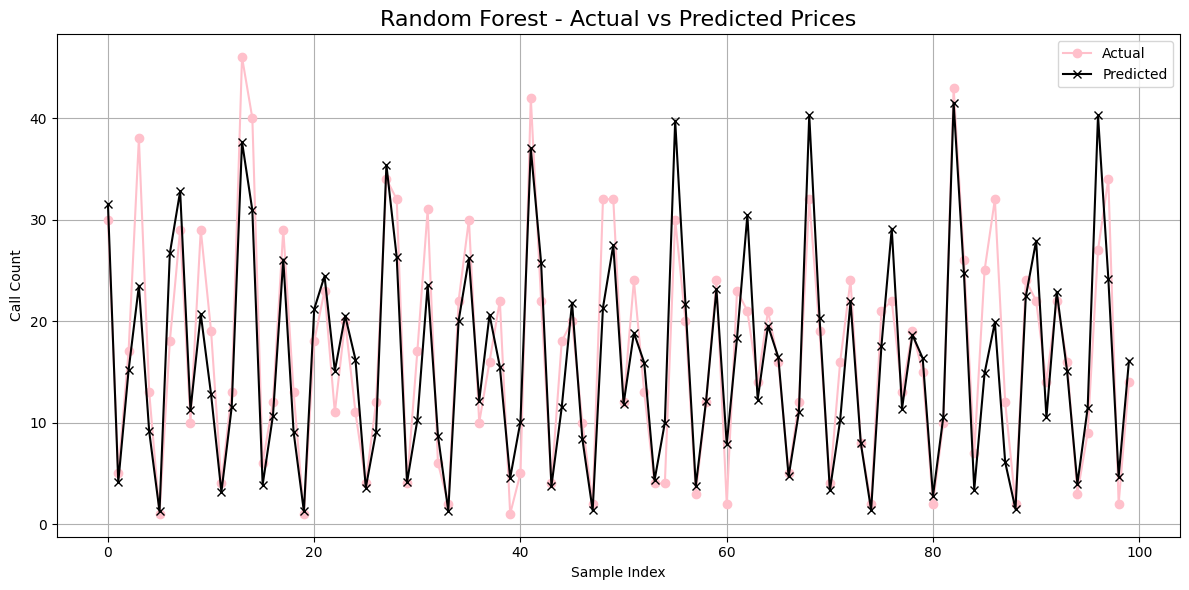

In [14]:
plot_actual_vs_predicted(y_test.values, y_pred, title="Random Forest - Actual vs Predicted Prices")

## Model-2 XGBRegressor

In [15]:
!pip install xgboost

In [16]:
from xgboost import XGBRegressor

In [17]:
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4)
xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [18]:
xgb_preds = xgb.predict(x_test)
print(xgb_preds)

[27.089056  4.791814 15.228305 ... 10.989929 40.726322 19.396858]


In [19]:
y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(xgb_preds)

# Create DataFrame with first 
results = pd.DataFrame({
    "Actual": y_test_flat[:100],
    "Predicted": y_pred_flat[:100]
})

print(results)

    Actual  Predicted
0       30  27.089056
1        5   4.791814
2       17  15.228305
3       38  22.844593
4       13   9.495976
..     ...        ...
95       9  10.525105
96      27  37.741180
97      34  25.582932
98       2   4.575039
99      14  14.816637

[100 rows x 2 columns]


In [33]:
mae = mean_absolute_error(y_test, xgb_preds)
rmse = mean_squared_error(y_test, xgb_preds) ** 0.5 
r2 = r2_score(y_test, xgb_preds)

print("XG Boost Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 Score: {r2}")

XG Boost Regressor Performance:
Mean Absolute Error (MAE): 3.3162734508514404
Root Mean Squared Error (RMSE): 4.533955154594283
R^2 Score: 0.8358341455459595


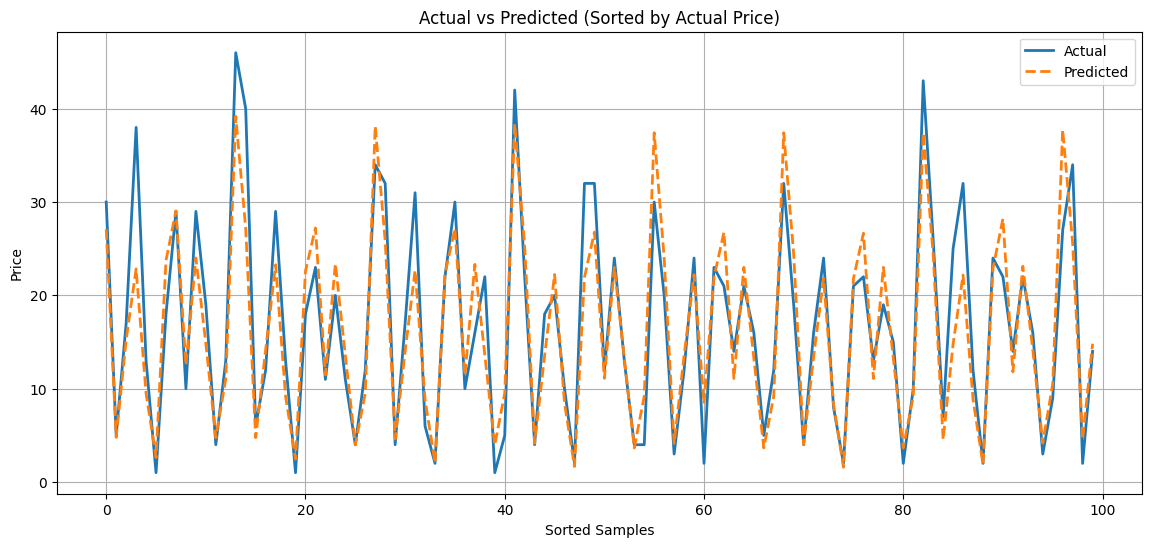

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))


plt.plot(results["Actual"][:200].values, label="Actual", linewidth=2)
plt.plot(results["Predicted"][:200].values, label="Predicted", linestyle='--', linewidth=2)

plt.title("Actual vs Predicted (Sorted by Actual Price)")
plt.xlabel("Sorted Samples")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
import os
os.makedirs("models", exist_ok = True)
import joblib
joblib.dump(xgb, "models/xgb.pkl")

['models/xgb.pkl']

## MLP

In [23]:
!pip install tensorflow

In [24]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

In [25]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [26]:
x_train_scaled

array([[-1.55190475, -1.55002294, -1.59155449, ...,  0.70365585,
         1.25917272, -1.35899624],
       [-1.36542328, -1.55002294, -1.59155449, ...,  0.70365585,
         1.25917272, -1.35899624],
       [-1.17894182, -1.55002294, -1.59155449, ...,  0.70365585,
         1.25917272, -1.35899624],
       ...,
       [ 0.87235425,  1.59716312,  1.04598463, ..., -1.21699503,
         0.73829376,  1.3519911 ],
       [ 1.05883571,  1.59716312,  1.04598463, ..., -1.21699503,
         0.73829376,  1.3519911 ],
       [ 1.24531717,  1.59716312,  1.04598463, ..., -1.21699503,
         0.73829376,  1.3519911 ]])

In [27]:
y_train_flat = np.ravel(y_train)
y_test_flat = np.ravel(y_test)

## TensorFlow MLP Model

In [28]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1)   # Output layer for regression
])


model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [29]:
history = model.fit(
    x_train_scaled,
    y_train_flat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 107.5846 - mae: 8.6248 - val_loss: 102.1916 - val_mae: 8.5385
Epoch 2/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 94.5335 - mae: 8.1488 - val_loss: 85.3348 - val_mae: 7.7594
Epoch 3/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 79.4691 - mae: 7.3430 - val_loss: 75.5745 - val_mae: 7.2817
Epoch 4/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 73.8008 - mae: 7.0313 - val_loss: 70.3061 - val_mae: 6.9129
Epoch 5/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 65.9988 - mae: 6.5486 - val_loss: 62.4514 - val_mae: 6.3946
Epoch 6/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 59.0638 - mae: 6.1371 - val_loss: 61.2992 - val_mae: 6.2746
Epoch 7/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 53.5415 - mae: 5.8129 - val_loss: 52.6250 - val_mae: 5.7666
Epoch 8/100
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 49.0319 - mae: 5.5451 - val_loss: 47.4757 - val_mae: 5.4967
Epoch 9/100
10

***Prediction***

In [ ]:
y_pred = model.predict(x_test_scaled)

# Flatten predictions
y_pred_flat = np.ravel(y_pred)

# Compare Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test_flat[:10],
    "Predicted": y_pred_flat[:10]
})

print("
First 10 Predictions:")
print(results)


****Model Evaluation****

In [30]:
mae = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
r2 = r2_score(y_test_flat, y_pred_flat)

print("\nTensorFlow MLP Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 Score: {r2}")


TensorFlow MLP Regressor Performance:
Mean Absolute Error (MAE): 3.3162734508514404
Root Mean Squared Error (RMSE): 4.533955154594283
R^2 Score: 0.8358341455459595


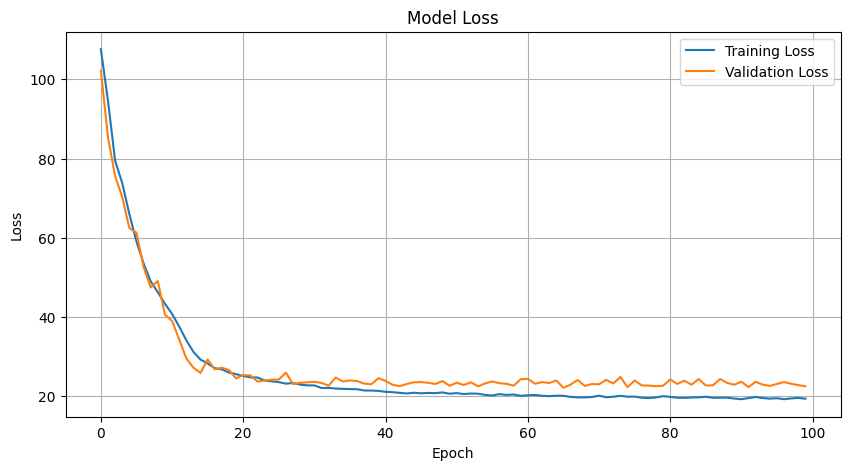

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

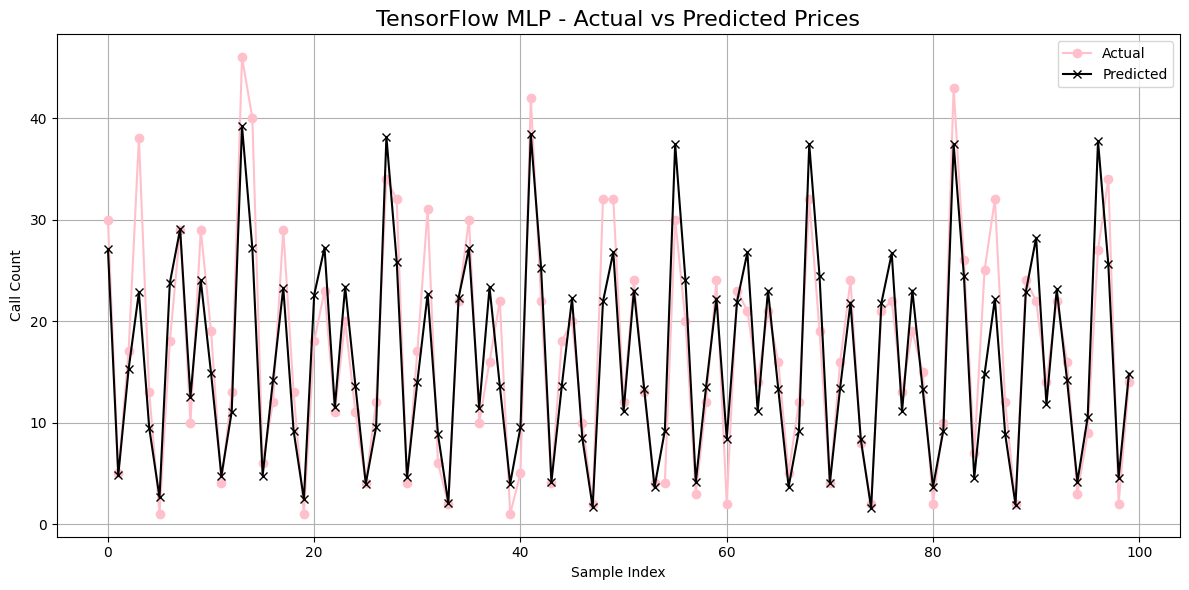

In [32]:
def plot_actual_vs_predicted(y_test, y_pred, title="Actual vs Predicted"):

    plt.figure(figsize=(12, 6))

    n = min(100, len(y_test))

    plt.plot(
        np.arange(n),
        y_test[:n],
        label='Actual',
        marker='o',
        color='pink'
    )

    plt.plot(
        np.arange(n),
        y_pred[:n],
        label='Predicted',
        marker='x',
        color='black'
    )

    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index')
    plt.ylabel('Call Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot Graph
plot_actual_vs_predicted(
    y_test_flat,
    y_pred_flat,
    title="TensorFlow MLP - Actual vs Predicted Prices"
)